# Phase 8 — Label-Based Validation: Microstructure Features
**HFTExperiment v2 · pre-release-v0.5.4.0**

Date: 2026-05-06 · Dataset: `training_ready.npz` (5,680,771 XAUUSD M1 bars)  
Mode: **Label-based** — KS, MI, redundancy, temporal profiling against 3-class ATR-adaptive labels  
Candidates: `adverse_selection_proxy`, `order_processing_residual`, `hawkes_excitation_5`, `hawkes_excitation_96`, `inventory_pressure_vio`

Pass criteria (all three required for supervised branch inclusion):
1. **KS D > 0.05** (sell vs hold distributional separation)
2. **MI > 0.005** (above OHLCV baseline mean = 0.00559)
3. **Redundancy ratio < 0.30** (max pairwise MI / label MI)

Temporal profiling and regime-conditional analysis run regardless of pass/fail verdict.


## 1. Setup & Data Loading

In [1]:
import sys, os, json, warnings
warnings.filterwarnings("ignore")

# ── Path setup ───────────────────────────────────────────────────────────────
repo_root = r"D:\HFTExperiment"   # hardcode project root for clarity
sys.path.insert(0, repo_root)

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer
from loguru import logger

# ── Load NPZ ─────────────────────────────────────────────────────────────────
NPZ_PATH = os.path.join(repo_root, "data", "training_ready.npz")

if not os.path.exists(NPZ_PATH):
    raise FileNotFoundError(f"NPZ file not found at: {NPZ_PATH}")

data = np.load(NPZ_PATH, allow_pickle=True)

close           = data["close"].astype(np.float64)
high            = data["high"].astype(np.float64)
low             = data["low"].astype(np.float64)
labels          = data["labels"].astype(np.int64)      # 0=sell 1=hold 2=buy
features_10d    = data["features"].astype(np.float32)  # (N, 10) baseline
gmm2            = data["gmm2"].astype(np.float32)      # 0=Bear 1=Bull
timestamps_ns   = data["timestamps_ns"].astype(np.int64)

HAS_TICKVOL = "tick_volume_raw" in data.files
if HAS_TICKVOL:
    tick_volume_raw = data["tick_volume_raw"].astype(np.int32)
    logger.info(f"tick_volume_raw loaded: min={tick_volume_raw.min()} max={tick_volume_raw.max()}")
else:
    logger.warning("tick_volume_raw not in NPZ — inventory_pressure_vio will be SKIPPED")
    logger.warning("Run precompute_features.py with Phase 8 patch to enable VIO.")

N = len(close)
meta = json.loads(str(data["metadata"]))
logger.info(f"NPZ: N={N:,} bars | created: {meta.get('created','?')}")
logger.info(f"Labels: sell={np.sum(labels==0):,} hold={np.sum(labels==1):,} buy={np.sum(labels==2):,}")


2026-05-06 23:18:00.391 | INFO     | __main__:<module>:36 - tick_volume_raw loaded: min=0 max=1748
2026-05-06 23:18:00.395 | INFO     | __main__:<module>:43 - NPZ: N=5,680,771 bars | created: 2026-05-06 16:10:23 UTC
2026-05-06 23:18:00.462 | INFO     | __main__:<module>:44 - Labels: sell=199,523 hold=5,439,333 buy=41,915


## 2. Feature Computation

In [2]:
# ── Utility functions ────────────────────────────────────────────────────────
def rolling_zscore(arr, window=120, eps=1e-8):
    """Causal rolling z-score with tanh clipping. O(N*window) — use on full series."""
    arr = arr.astype(np.float64)
    n   = len(arr)
    out = np.empty(n, dtype=np.float32)
    for i in range(n):
        lo  = max(0, i - window + 1)
        win = arr[lo:i+1]
        mu, sig = win.mean(), win.std()
        out[i]  = float(np.tanh((arr[i] - mu) / (sig + eps)))
    return out

def wilder_atr(h, l, c, period=14):
    n   = len(c)
    tr  = np.maximum(h[1:]-l[1:], np.maximum(np.abs(h[1:]-c[:-1]), np.abs(l[1:]-c[:-1])))
    tr  = np.concatenate([[tr[0]], tr])
    atr = np.empty(n); atr[0] = tr[0]; a = 1.0/period
    for i in range(1, n): atr[i] = atr[i-1]*(1-a)+tr[i]*a
    return atr

logger.info("Utility functions defined.")


2026-05-06 23:18:00.492 | INFO     | __main__:<module>:22 - Utility functions defined.


In [3]:
# ── adverse_selection_proxy ──────────────────────────────────────────────────
# Hagströmer (2021) spread decomposition: permanent vs transitory price impact.
# perm_revision = mid_t+1 - mid_t  (proxy: close_t+1 - close_t)
# temp_revision = -(close_t - mid_t) approximated as -(close_t - (high_t+low_t)/2)
# adverse_selection = perm / (perm + |temp| + eps)
logger.info("Computing adverse_selection_proxy...")
mid        = (high + low) / 2.0
perm       = np.concatenate([np.diff(close), [0.0]])        # forward difference
temp       = -(close - mid)
adv_sel    = perm / (np.abs(perm) + np.abs(temp) + 1e-8)
adverse_selection_proxy = rolling_zscore(adv_sel, window=120)
logger.info(f"  adverse_selection_proxy: mean={adverse_selection_proxy.mean():.4f} "
            f"std={adverse_selection_proxy.std():.4f} "
            f"skew={float(stats.skew(adverse_selection_proxy)):.3f} "
            f"kurt={float(stats.kurtosis(adverse_selection_proxy)):.3f}")


2026-05-06 23:18:00.519 | INFO     | __main__:<module>:6 - Computing adverse_selection_proxy...
2026-05-06 23:23:22.238 | INFO     | __main__:<module>:12 -   adverse_selection_proxy: mean=0.0004 std=0.7045 skew=-0.002 kurt=-1.731


In [4]:
# ── order_processing_residual ────────────────────────────────────────────────
# Spread residual after removing adverse selection component.
# Measures market-maker cost of order processing, orthogonal to directional impact.
# spread_raw = high - low (proxy for quoted spread)
# atr_spread = Wilder ATR(14) as baseline volatility estimate
# residual = (spread_raw - atr_spread) / atr_spread
logger.info("Computing order_processing_residual...")
spread_raw = (high - low).astype(np.float64)
atr14      = wilder_atr(high, low, close, period=14)
opr_raw    = (spread_raw - atr14) / (atr14 + 1e-8)
order_processing_residual = rolling_zscore(opr_raw, window=120)
logger.info(f"  order_processing_residual: mean={order_processing_residual.mean():.4f} "
            f"std={order_processing_residual.std():.4f} "
            f"skew={float(stats.skew(order_processing_residual)):.3f} "
            f"kurt={float(stats.kurtosis(order_processing_residual)):.3f}")


2026-05-06 23:23:22.366 | INFO     | __main__:<module>:7 - Computing order_processing_residual...


2026-05-06 23:28:46.801 | INFO     | __main__:<module>:12 -   order_processing_residual: mean=-0.0741 std=0.5910 skew=0.379 kurt=-1.160


In [5]:
# ── hawkes_excitation (τ=5 and τ=96) ─────────────────────────────────────────
# Exponentially-weighted self-excitation intensity of the return process.
# I[t] = I[t-1]*exp(-1/τ) + |r[t]|  (causal IIR — O(N), exact)
# τ=5  → fast kernel (ACF decays in ~5 bars, microstructure timescale)
# τ=96 → corrected empirical Hawkes kernel (Phase 7v2 consecutive-segment ACF)
#         captures macro momentum persistence at M1 resolution
logger.info("Computing hawkes_excitation (τ=5 and τ=96)...")
log_abs_ret = np.abs(np.concatenate([[0.0], np.log(close[1:]/(close[:-1]+1e-8))]))

def hawkes_excitation(log_abs_ret, tau):
    alpha = np.exp(-1.0 / tau)
    n     = len(log_abs_ret)
    intensity = np.empty(n, dtype=np.float64)
    intensity[0] = log_abs_ret[0]
    for i in range(1, n):
        intensity[i] = intensity[i-1]*alpha + log_abs_ret[i]
    return rolling_zscore(intensity, window=120)

hawkes_excitation_5  = hawkes_excitation(log_abs_ret, tau=5)
hawkes_excitation_96 = hawkes_excitation(log_abs_ret, tau=96)

for name, feat in [("hawkes_excitation_5", hawkes_excitation_5),
                   ("hawkes_excitation_96", hawkes_excitation_96)]:
    logger.info(f"  {name}: mean={feat.mean():.4f} std={feat.std():.4f} "
                f"skew={float(stats.skew(feat)):.3f} kurt={float(stats.kurtosis(feat)):.3f}")


2026-05-06 23:28:46.887 | INFO     | __main__:<module>:7 - Computing hawkes_excitation (τ=5 and τ=96)...
2026-05-06 23:38:38.406 | INFO     | __main__:<module>:24 -   hawkes_excitation_5: mean=-0.0743 std=0.6554 skew=0.304 kurt=-1.361
2026-05-06 23:38:38.613 | INFO     | __main__:<module>:24 -   hawkes_excitation_96: mean=-0.0885 std=0.8168 skew=0.195 kurt=-1.764


In [6]:
# ── inventory_pressure_vio ───────────────────────────────────────────────────
# Volume Imbalance Order: VIO[t] = Σ(V_k × sign_k) / Σ(V_k)  over rolling W=20 bars
# Requires tick_volume_raw (int32) — skipped if not in NPZ.
# sign_k = sign(close_k - open_k) from OHLCV (proxy for trade direction)
# Result is bounded (-1, 1) — no zero-inflation when using raw volume denominators.

if HAS_TICKVOL:
    logger.info("Computing inventory_pressure_vio (VIO formula)...")
    # open is not in NPZ — reconstruct from close[t-1] as proxy for mid-bar direction
    # True open requires raw OHLCV; use high/low midpoint as proxy
    bar_direction = np.sign(close - (high + low) / 2.0).astype(np.float64)
    W             = 20
    n             = len(close)
    vio           = np.empty(n, dtype=np.float32)
    vol_f         = tick_volume_raw.astype(np.float64)
    for i in range(n):
        lo      = max(0, i - W + 1)
        num     = np.sum(vol_f[lo:i+1] * bar_direction[lo:i+1])
        den     = np.sum(vol_f[lo:i+1]) + 1e-8
        vio[i]  = float(num / den)
    inventory_pressure_vio = vio
    logger.info(f"  inventory_pressure_vio: mean={vio.mean():.4f} std={vio.std():.4f} "
                f"skew={float(stats.skew(vio)):.3f} kurt={float(stats.kurtosis(vio)):.3f}")
else:
    inventory_pressure_vio = None
    logger.warning("inventory_pressure_vio SKIPPED — tick_volume_raw not in NPZ")


2026-05-06 23:38:38.660 | INFO     | __main__:<module>:8 - Computing inventory_pressure_vio (VIO formula)...
2026-05-06 23:39:26.593 | INFO     | __main__:<module>:22 -   inventory_pressure_vio: mean=0.0005 std=0.0300 skew=3.578 kurt=219.989


In [7]:
# ── Candidate registry ───────────────────────────────────────────────────────
candidates = {
    "adverse_selection_proxy":  adverse_selection_proxy,
    "order_processing_residual": order_processing_residual,
    "hawkes_excitation_5":      hawkes_excitation_5,
    "hawkes_excitation_96":     hawkes_excitation_96,
}
if inventory_pressure_vio is not None:
    candidates["inventory_pressure_vio"] = inventory_pressure_vio

BASELINE_NAMES = [
    "open_sc","high_sc","low_sc","close_sc","tickvol_sc",
    "spread_sc","bar_return_bps","wick_asymmetry","vol_zscore","spread_pressure"
]
logger.info(f"Candidates ready: {list(candidates.keys())}")
logger.info(f"Baseline features: {BASELINE_NAMES}")


2026-05-06 23:39:26.627 | INFO     | __main__:<module>:15 - Candidates ready: ['adverse_selection_proxy', 'order_processing_residual', 'hawkes_excitation_5', 'hawkes_excitation_96', 'inventory_pressure_vio']
2026-05-06 23:39:26.629 | INFO     | __main__:<module>:16 - Baseline features: ['open_sc', 'high_sc', 'low_sc', 'close_sc', 'tickvol_sc', 'spread_sc', 'bar_return_bps', 'wick_asymmetry', 'vol_zscore', 'spread_pressure']


## 3. KS Distributional Separation

Threshold: **D > 0.05**

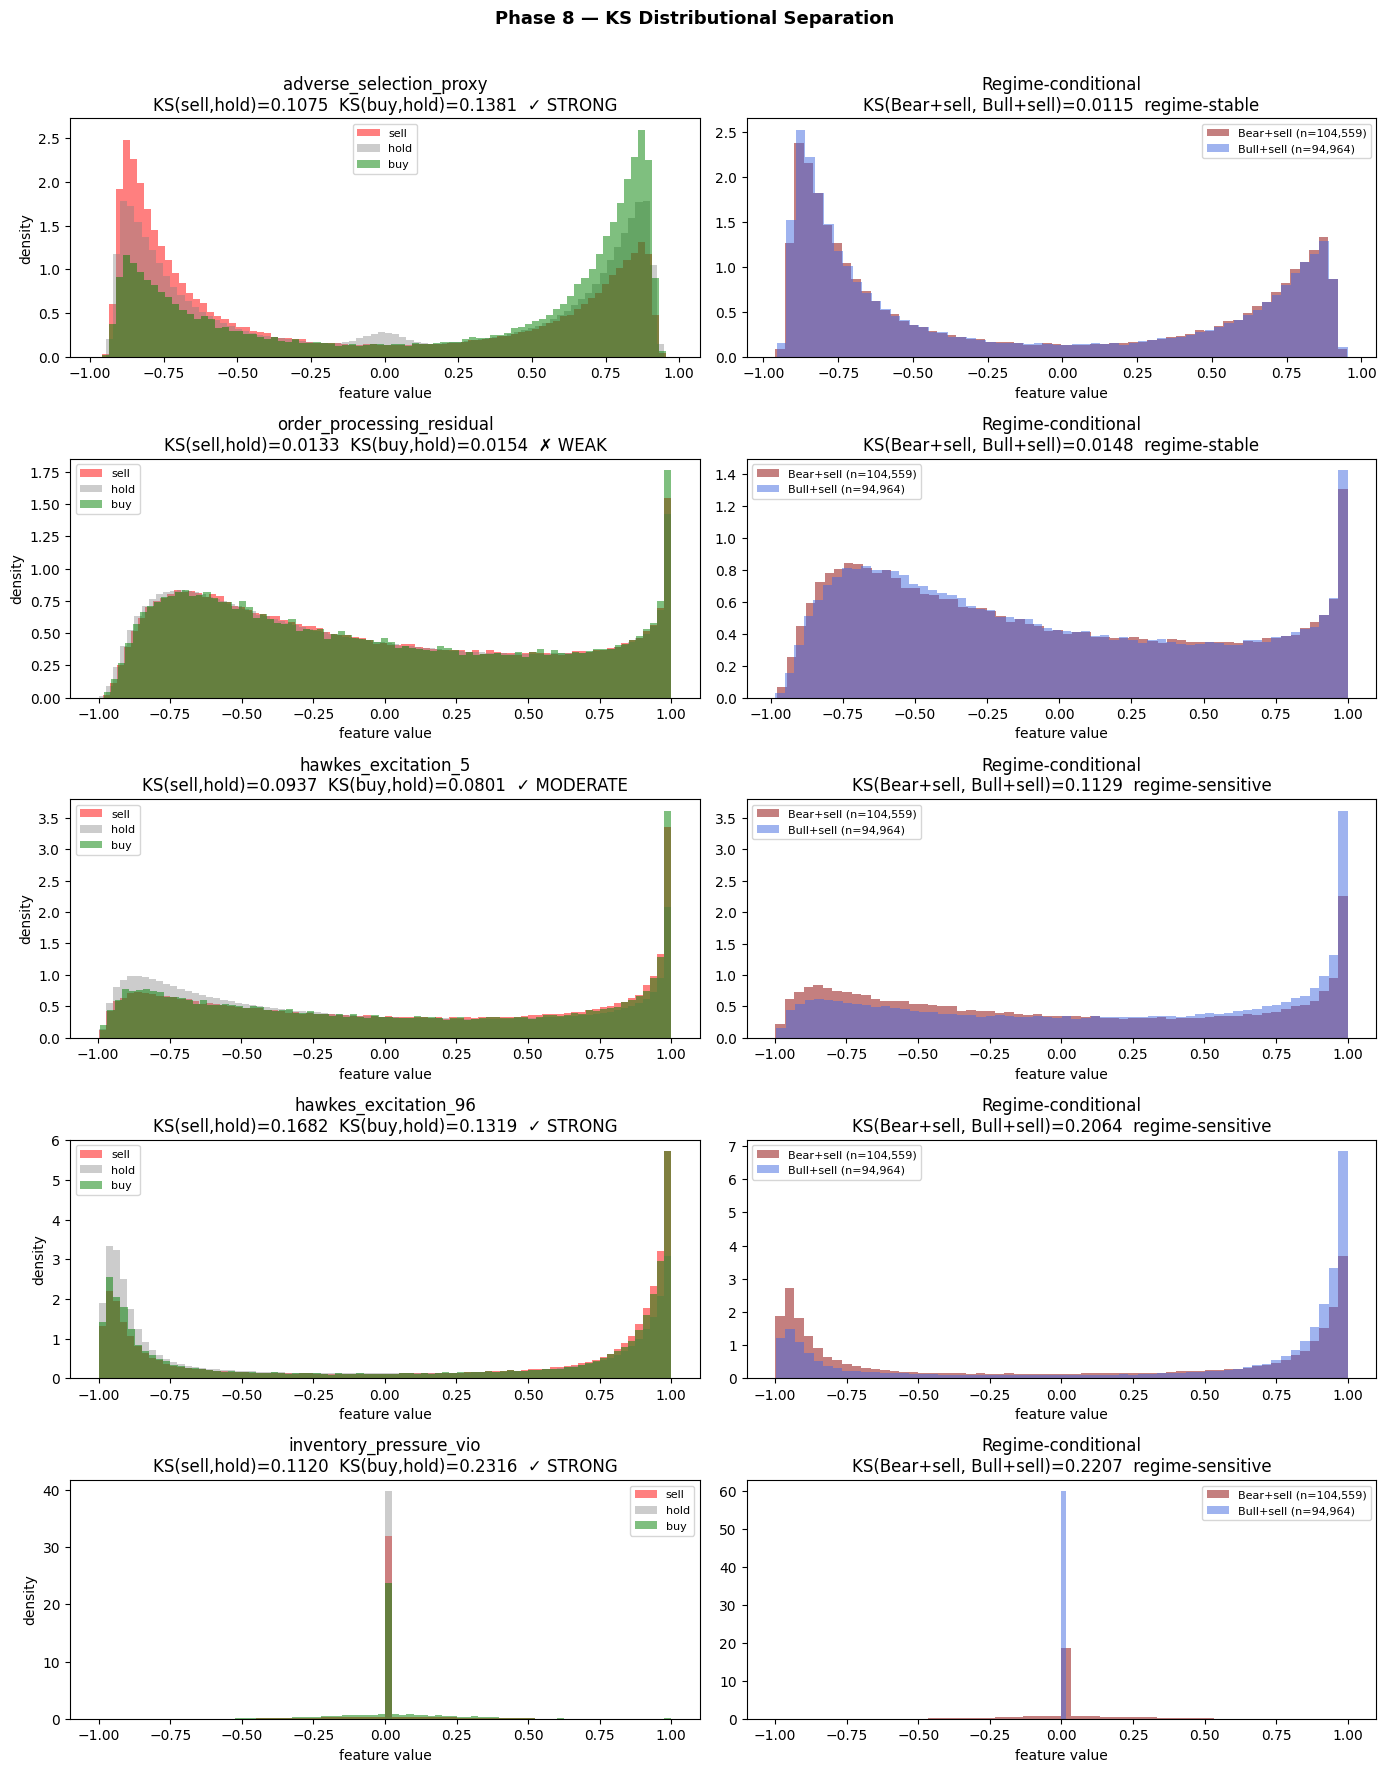


=== KS Results ===
Feature                            KS(sell)    KS(buy)   Regime-D  Signal
---------------------------------------------------------------------------
  adverse_selection_proxy            0.1075     0.1381     0.0115  [PASS] ✓ STRONG
  order_processing_residual          0.0133     0.0154     0.0148  [FAIL] ✗ WEAK
  hawkes_excitation_5                0.0937     0.0801     0.1129  [PASS] ✓ MODERATE
  hawkes_excitation_96               0.1682     0.1319     0.2064  [PASS] ✓ STRONG
  inventory_pressure_vio             0.1120     0.2316     0.2207  [PASS] ✓ STRONG


In [8]:
sell_mask = labels == 0
hold_mask = labels == 1
buy_mask  = labels == 2
KS_THRESHOLD = 0.05

ks_results = {}
fig, axes = plt.subplots(len(candidates), 2, figsize=(14, 3.5*len(candidates)))
if len(candidates) == 1: axes = axes[None]

for idx, (name, feat) in enumerate(candidates.items()):
    d_sv, p_sv = stats.ks_2samp(feat[sell_mask], feat[hold_mask])
    d_bv, p_bv = stats.ks_2samp(feat[buy_mask],  feat[hold_mask])
    signal     = "✓ STRONG" if d_sv > 0.10 else ("✓ MODERATE" if d_sv > KS_THRESHOLD else "✗ WEAK")
    ks_results[name] = {"ks_sell": d_sv, "ks_buy": d_bv, "signal": signal}

    # Sequence profile: mean feature value per bar position (sell vs hold vs buy)
    # Use a random 5k-sequence sample to keep memory tractable
    rng = np.random.default_rng(42)
    SAMPLE = min(5000, sell_mask.sum())
    s_idx = rng.choice(np.where(sell_mask)[0], SAMPLE, replace=False)
    h_idx = rng.choice(np.where(hold_mask)[0], SAMPLE, replace=False)
    b_idx = rng.choice(np.where(buy_mask)[0],  min(SAMPLE, buy_mask.sum()), replace=False)

    ax1, ax2 = axes[idx]
    ax1.hist(feat[sell_mask], bins=80, alpha=0.5, label="sell", density=True, color="red")
    ax1.hist(feat[hold_mask], bins=80, alpha=0.4, label="hold", density=True, color="gray")
    ax1.hist(feat[buy_mask],  bins=80, alpha=0.5, label="buy",  density=True, color="green")
    ax1.set_title(f"{name}\nKS(sell,hold)={d_sv:.4f}  KS(buy,hold)={d_bv:.4f}  {signal}")
    ax1.legend(fontsize=8)
    ax1.set_xlabel("feature value"); ax1.set_ylabel("density")

    # Regime-conditional: Bear+sell vs Bull+sell
    bear_sell = sell_mask & (gmm2 < 0.5)
    bull_sell = sell_mask & (gmm2 >= 0.5)
    d_reg, _ = stats.ks_2samp(feat[bear_sell], feat[bull_sell])
    ax2.hist(feat[bear_sell], bins=60, alpha=0.5, label=f"Bear+sell (n={bear_sell.sum():,})", density=True, color="darkred")
    ax2.hist(feat[bull_sell], bins=60, alpha=0.5, label=f"Bull+sell (n={bull_sell.sum():,})", density=True, color="royalblue")
    ax2.set_title(f"Regime-conditional\nKS(Bear+sell, Bull+sell)={d_reg:.4f}  "
                  f"{'regime-sensitive' if d_reg>0.10 else 'regime-stable'}")
    ax2.legend(fontsize=8)
    ax2.set_xlabel("feature value")

    ks_results[name]["ks_regime"] = d_reg
    ks_results[name]["regime_sensitive"] = d_reg > 0.10

plt.suptitle("Phase 8 — KS Distributional Separation", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("phase8_ks.png", dpi=120, bbox_inches="tight"); plt.show()

print("\n=== KS Results ===")
print(f"{'Feature':<32} {'KS(sell)':>10} {'KS(buy)':>10} {'Regime-D':>10}  Signal")
print("-"*75)
for name, r in ks_results.items():
    flag = "PASS" if r["ks_sell"] > KS_THRESHOLD else "FAIL"
    print(f"  {name:<30} {r['ks_sell']:>10.4f} {r['ks_buy']:>10.4f} "
          f"{r['ks_regime']:>10.4f}  [{flag}] {r['signal']}")


## 4. Mutual Information

Threshold: **MI > 0.005** (OHLCV baseline mean = 0.00559)

2026-05-06 23:39:42.308 | INFO     | __main__:<module>:12 - Computing baseline MIs...
2026-05-06 23:39:45.059 | INFO     | __main__:<module>:16 -   open_sc: MI=0.00046
2026-05-06 23:39:46.534 | INFO     | __main__:<module>:16 -   high_sc: MI=0.00056
2026-05-06 23:39:47.832 | INFO     | __main__:<module>:16 -   low_sc: MI=0.00050
2026-05-06 23:39:49.141 | INFO     | __main__:<module>:16 -   close_sc: MI=0.00050
2026-05-06 23:39:49.906 | INFO     | __main__:<module>:16 -   tickvol_sc: MI=0.00000
2026-05-06 23:39:50.683 | INFO     | __main__:<module>:16 -   spread_sc: MI=0.00000
2026-05-06 23:39:52.216 | INFO     | __main__:<module>:16 -   bar_return_bps: MI=0.01222
2026-05-06 23:39:53.798 | INFO     | __main__:<module>:16 -   wick_asymmetry: MI=0.00290
2026-05-06 23:39:54.755 | INFO     | __main__:<module>:16 -   vol_zscore: MI=0.01279
2026-05-06 23:39:56.174 | INFO     | __main__:<module>:16 -   spread_pressure: MI=0.05407
2026-05-06 23:39:56.175 | INFO     | __main__:<module>:18 - Comp

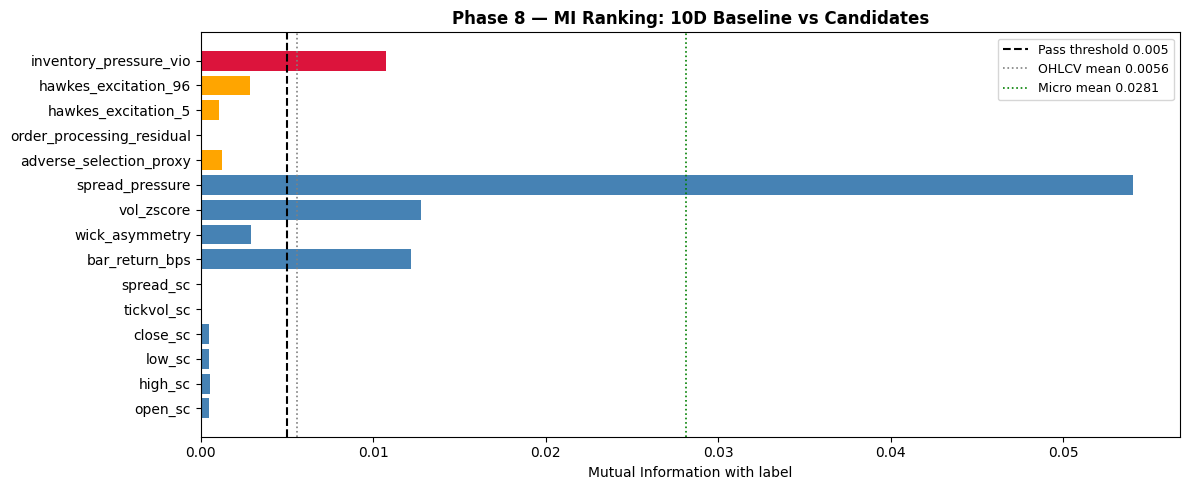


=== MI Results ===
Feature                                MI   vs_OHLCV   vs_Micro  Verdict
----------------------------------------------------------------------
  adverse_selection_proxy         0.00125       0.22x       0.04x  [FAIL]
  order_processing_residual       0.00005       0.01x       0.00x  [FAIL]
  hawkes_excitation_5             0.00103       0.19x       0.04x  [FAIL]
  hawkes_excitation_96            0.00285       0.51x       0.10x  [FAIL]
  inventory_pressure_vio          0.01076       1.92x       0.38x  [PASS]


In [9]:
def compute_mi(feat, labels, n_bins=20):
    """Estimate MI between continuous feature and categorical label via binning."""
    kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
    feat_binned = kbd.fit_transform(feat.reshape(-1,1)).ravel().astype(int)
    return mutual_info_score(labels, feat_binned)

MI_THRESHOLD = 0.005
OHLCV_MEAN   = 0.00559
MICRO_MEAN   = 0.02814

# Baseline MIs for reference
logger.info("Computing baseline MIs...")
baseline_mi = {}
for i, name in enumerate(BASELINE_NAMES):
    baseline_mi[name] = compute_mi(features_10d[:, i], labels)
    logger.info(f"  {name}: MI={baseline_mi[name]:.5f}")

logger.info("Computing candidate MIs...")
mi_results = {}
for name, feat in candidates.items():
    mi = compute_mi(feat, labels)
    mi_results[name] = {
        "mi":           mi,
        "vs_ohlcv":     mi / OHLCV_MEAN,
        "vs_micro":     mi / MICRO_MEAN,
        "pass":         mi > MI_THRESHOLD,
    }
    logger.info(f"  {name}: MI={mi:.5f} ({mi/OHLCV_MEAN:.2f}x OHLCV mean)")

# Plot MI ranking
fig, ax = plt.subplots(figsize=(12, 5))
all_names = BASELINE_NAMES + list(candidates.keys())
all_mis   = [baseline_mi[n] for n in BASELINE_NAMES] + [mi_results[n]["mi"] for n in candidates]
colors    = ["steelblue"]*10 + ["crimson" if mi_results[n]["pass"] else "orange"
                                 for n in candidates]
bars = ax.barh(all_names, all_mis, color=colors)
ax.axvline(MI_THRESHOLD, color="black", ls="--", lw=1.5, label=f"Pass threshold {MI_THRESHOLD}")
ax.axvline(OHLCV_MEAN,   color="gray",  ls=":",  lw=1.2, label=f"OHLCV mean {OHLCV_MEAN:.4f}")
ax.axvline(MICRO_MEAN,   color="green", ls=":",  lw=1.2, label=f"Micro mean {MICRO_MEAN:.4f}")
ax.set_xlabel("Mutual Information with label"); ax.legend(fontsize=9)
ax.set_title("Phase 8 — MI Ranking: 10D Baseline vs Candidates", fontweight="bold")
plt.tight_layout(); plt.savefig("phase8_mi.png", dpi=120, bbox_inches="tight"); plt.show()

print("\n=== MI Results ===")
print(f"{'Feature':<32} {'MI':>8} {'vs_OHLCV':>10} {'vs_Micro':>10}  Verdict")
print("-"*70)
for name, r in mi_results.items():
    flag = "PASS" if r["pass"] else "FAIL"
    print(f"  {name:<30} {r['mi']:>8.5f} {r['vs_ohlcv']:>10.2f}x {r['vs_micro']:>10.2f}x  [{flag}]")


## 5. Temporal Profiling (240-bar Depth)

Per-bar Cohen's d — determines stream assignment: short (w=20) vs long Transformer.

2026-05-06 23:40:03.303 | INFO     | __main__:<module>:28 - Running temporal profiling (this may take ~5 minutes)...
2026-05-06 23:40:03.304 | INFO     | __main__:<module>:30 -   Profiling adverse_selection_proxy...
2026-05-06 23:40:03.818 | INFO     | __main__:<module>:35 -     early_d=0.0199  late_d=0.0266  late_ks=0.0293  → long
2026-05-06 23:40:03.818 | INFO     | __main__:<module>:30 -   Profiling order_processing_residual...
2026-05-06 23:40:04.333 | INFO     | __main__:<module>:35 -     early_d=0.0228  late_d=0.0175  late_ks=0.0260  → long
2026-05-06 23:40:04.334 | INFO     | __main__:<module>:30 -   Profiling hawkes_excitation_5...
2026-05-06 23:40:04.807 | INFO     | __main__:<module>:35 -     early_d=0.0931  late_d=0.1812  late_ks=0.0880  → short (w=20)
2026-05-06 23:40:04.808 | INFO     | __main__:<module>:30 -   Profiling hawkes_excitation_96...
2026-05-06 23:40:05.286 | INFO     | __main__:<module>:35 -     early_d=0.1013  late_d=0.3414  late_ks=0.1605  → short (w=20)
2026

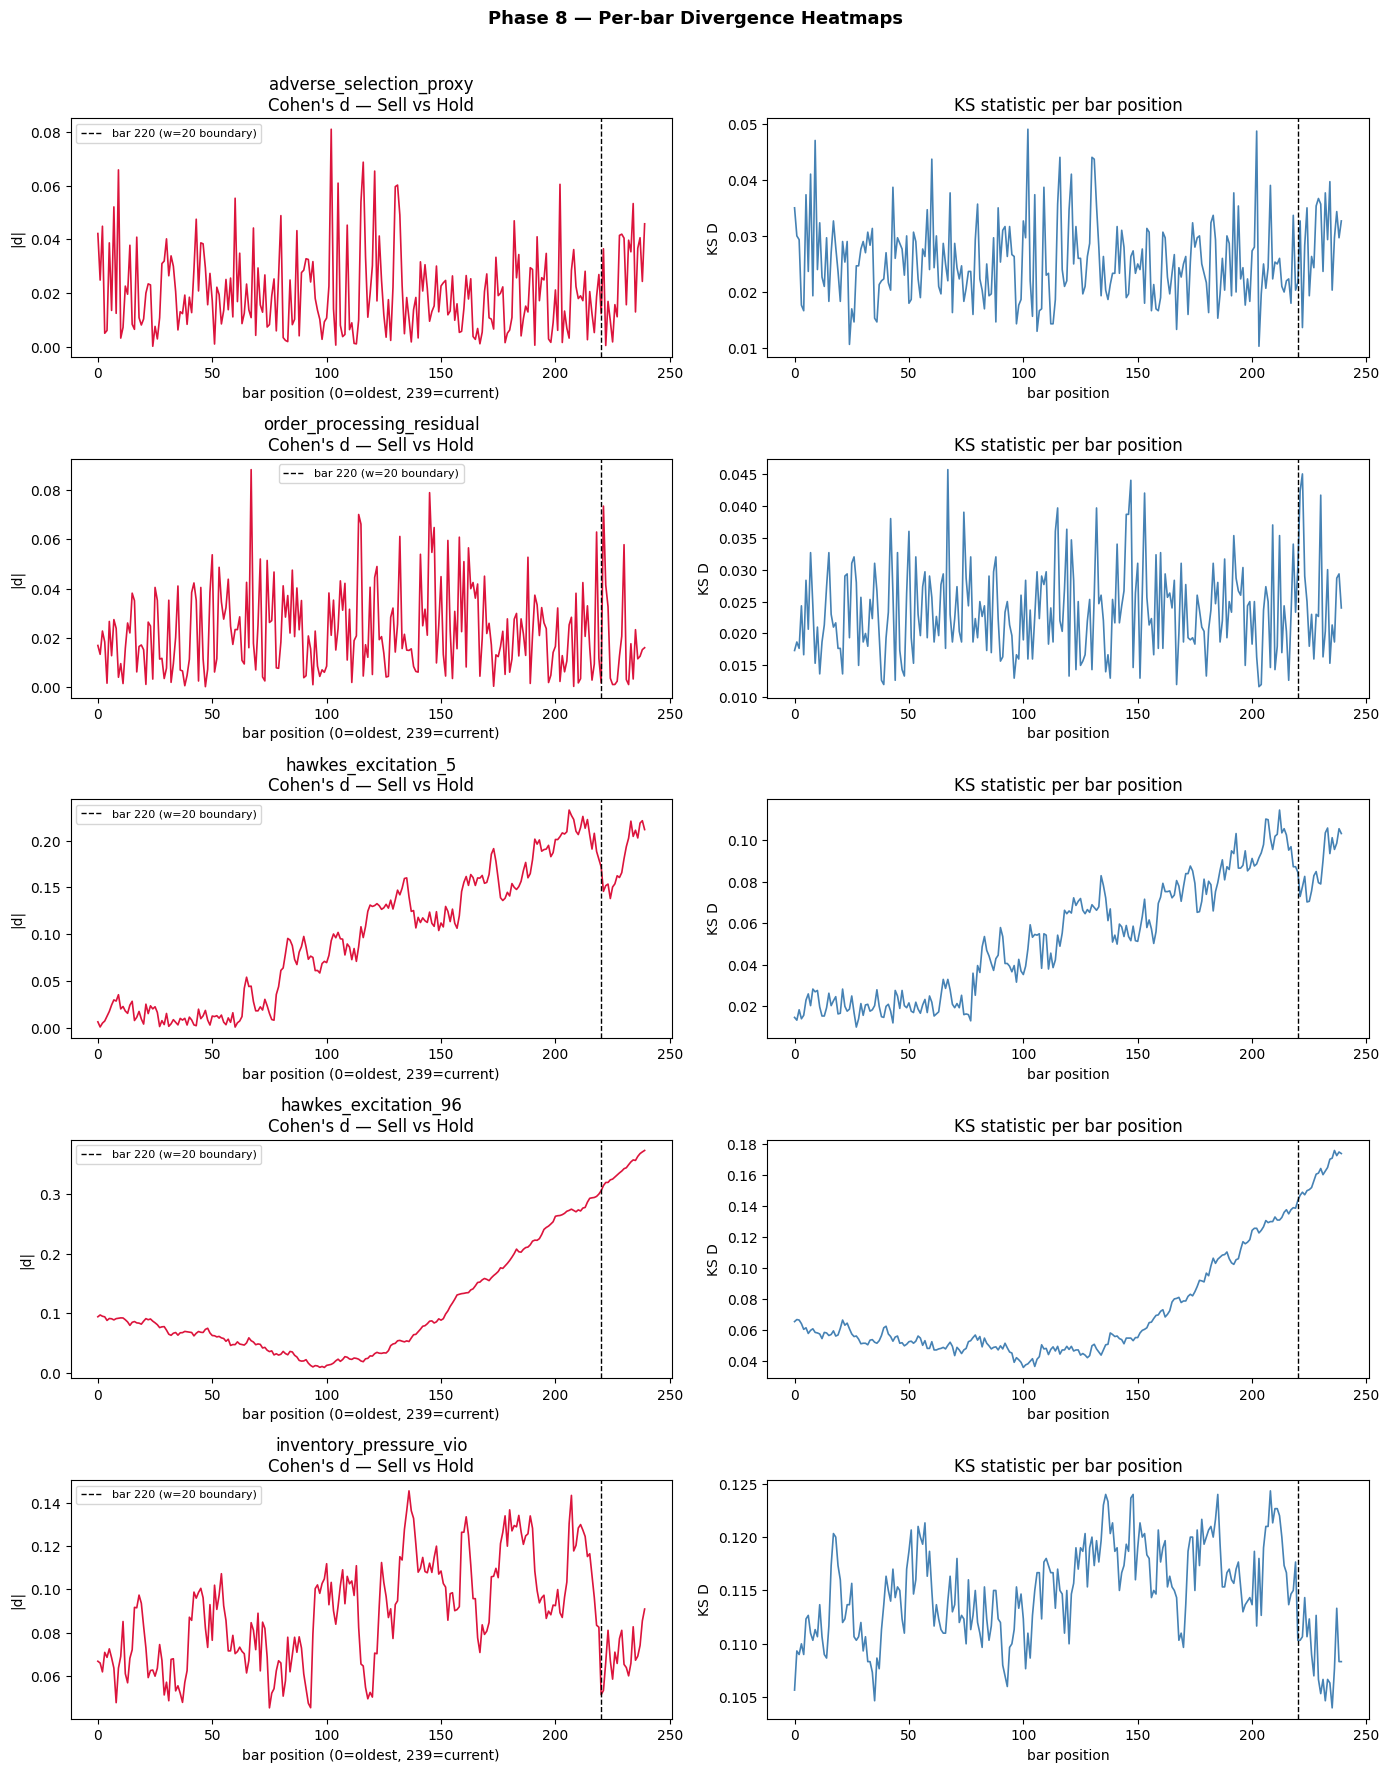


=== Temporal Profiling Summary ===
Feature                           Early d [0-220] Late d [220-240]    Late KS  Stream
-------------------------------------------------------------------------------------
  adverse_selection_proxy                  0.0199           0.0266     0.0293  long
  order_processing_residual                0.0228           0.0175     0.0260  long
  hawkes_excitation_5                      0.0931           0.1812     0.0880  short (w=20)
  hawkes_excitation_96                     0.1013           0.3414     0.1605  short (w=20)
  inventory_pressure_vio                   0.0900           0.0698     0.1088  long


In [10]:
SEQ_LEN  = 240
N_SAMPLE = 3000   # sequences to profile (memory bound)
rng      = np.random.default_rng(0)

def temporal_profile(feat, label_mask, n_sample=N_SAMPLE, seq_len=SEQ_LEN):
    """Per-bar Cohen's d and KS between label and hold across 240-bar lookback."""
    hold_mask = labels == 1
    sel_idx   = np.where(label_mask)[0]
    hld_idx   = np.where(hold_mask)[0]
    # only indices with full lookback
    sel_idx = sel_idx[sel_idx >= seq_len]
    hld_idx = hld_idx[hld_idx >= seq_len]
    sel_idx = rng.choice(sel_idx, min(n_sample, len(sel_idx)), replace=False)
    hld_idx = rng.choice(hld_idx, min(n_sample, len(hld_idx)), replace=False)
    cohens_d = np.empty(seq_len); ks_d = np.empty(seq_len)
    for pos in range(seq_len):
        offset = pos - seq_len  # negative index from current bar
        s_vals = feat[sel_idx + offset]
        h_vals = feat[hld_idx + offset]
        pooled_std = np.sqrt((s_vals.std()**2 + h_vals.std()**2) / 2) + 1e-8
        cohens_d[pos] = (s_vals.mean() - h_vals.mean()) / pooled_std
        cohens_d[pos] = abs(cohens_d[pos])
        ks_d[pos]     = stats.ks_2samp(s_vals, h_vals).statistic
    return cohens_d, ks_d

sell_mask = labels == 0
temporal  = {}
logger.info("Running temporal profiling (this may take ~5 minutes)...")
for name, feat in candidates.items():
    logger.info(f"  Profiling {name}...")
    cd, kd = temporal_profile(feat, sell_mask)
    temporal[name] = {"cohens_d": cd, "ks_d": kd}
    early_d = cd[:220].mean(); late_d = cd[220:].mean(); late_ks = kd[220:].mean()
    stream  = "short (w=20)" if late_d > early_d * 1.5 else "long"
    logger.info(f"    early_d={early_d:.4f}  late_d={late_d:.4f}  late_ks={late_ks:.4f}  → {stream}")

fig, axes = plt.subplots(len(candidates), 2, figsize=(14, 3.5*len(candidates)))
if len(candidates) == 1: axes = axes[None]
for idx, (name, t) in enumerate(temporal.items()):
    ax1, ax2 = axes[idx]
    ax1.plot(t["cohens_d"], color="crimson", lw=1.2)
    ax1.axvline(220, color="black", ls="--", lw=1, label="bar 220 (w=20 boundary)")
    ax1.set_title(f"{name}\nCohen's d — Sell vs Hold"); ax1.legend(fontsize=8)
    ax1.set_xlabel("bar position (0=oldest, 239=current)"); ax1.set_ylabel("|d|")
    ax2.plot(t["ks_d"], color="steelblue", lw=1.2)
    ax2.axvline(220, color="black", ls="--", lw=1)
    ax2.set_title("KS statistic per bar position"); ax2.set_xlabel("bar position")
    ax2.set_ylabel("KS D")
plt.suptitle("Phase 8 — Per-bar Divergence Heatmaps", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout(); plt.savefig("phase8_temporal.png", dpi=120, bbox_inches="tight"); plt.show()

print("\n=== Temporal Profiling Summary ===")
print(f"{'Feature':<32} {'Early d [0-220]':>16} {'Late d [220-240]':>16} {'Late KS':>10}  Stream")
print("-"*85)
for name, t in temporal.items():
    ed = t["cohens_d"][:220].mean(); ld = t["cohens_d"][220:].mean(); lk = t["ks_d"][220:].mean()
    stream = "short (w=20)" if ld > ed * 1.5 else "long"
    print(f"  {name:<30} {ed:>16.4f} {ld:>16.4f} {lk:>10.4f}  {stream}")


## 6. Redundancy Analysis

Ratio = max pairwise MI(candidate, existing) / MI(candidate, label)

Pass threshold: **ratio < 0.30**

2026-05-06 23:40:24.462 | INFO     | __main__:<module>:23 -   adverse_selection_proxy: ratio=42.763  max_pair=0.05338 (bar_return_bps)  adj_MI=0.00000
2026-05-06 23:40:39.533 | INFO     | __main__:<module>:23 -   order_processing_residual: ratio=3437.318  max_pair=0.16847 (spread_pressure)  adj_MI=0.00000
2026-05-06 23:40:53.520 | INFO     | __main__:<module>:23 -   hawkes_excitation_5: ratio=110.247  max_pair=0.11405 (bar_return_bps)  adj_MI=0.00000
2026-05-06 23:41:05.825 | INFO     | __main__:<module>:23 -   hawkes_excitation_96: ratio=21.924  max_pair=0.06241 (spread_pressure)  adj_MI=0.00000
2026-05-06 23:41:14.860 | INFO     | __main__:<module>:23 -   inventory_pressure_vio: ratio=2.620  max_pair=0.02818 (spread_pressure)  adj_MI=0.00230


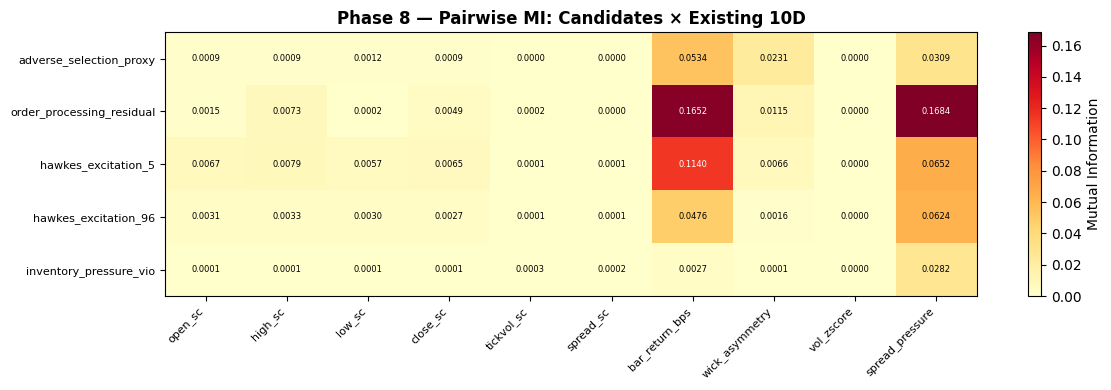


=== Redundancy Results ===
Feature                           Max pair MI   Label MI    Ratio    Adj MI  Verdict
-------------------------------------------------------------------------------------
  adverse_selection_proxy             0.05338    0.00125   42.763   0.00000  [FAIL]  (vs bar_return_bps)
  order_processing_residual           0.16847    0.00005 3437.318   0.00000  [FAIL]  (vs spread_pressure)
  hawkes_excitation_5                 0.11405    0.00103  110.247   0.00000  [FAIL]  (vs bar_return_bps)
  hawkes_excitation_96                0.06241    0.00285   21.924   0.00000  [FAIL]  (vs spread_pressure)
  inventory_pressure_vio              0.02818    0.01076    2.620   0.00230  [FAIL]  (vs spread_pressure)


In [11]:
REDUNDANCY_THRESHOLD = 0.30

redundancy = {}
for name, feat in candidates.items():
    label_mi    = mi_results[name]["mi"]
    max_pair_mi = 0.0
    max_pair_nm = ""
    for i, bname in enumerate(BASELINE_NAMES):
        pair_mi = compute_mi(feat, features_10d[:, i].astype(int))
        if pair_mi > max_pair_mi:
            max_pair_mi = pair_mi; max_pair_nm = bname
    ratio = max_pair_mi / (label_mi + 1e-10)
    # Continuous redundancy-adjusted MI (Phase 6 §9 recommendation)
    adj_mi = label_mi * max(0.0, 1.0 - ratio * 0.3)
    redundancy[name] = {
        "max_pairwise_mi":  max_pair_mi,
        "most_correlated":  max_pair_nm,
        "label_mi":         label_mi,
        "ratio":            ratio,
        "adj_mi":           adj_mi,
        "pass":             ratio < REDUNDANCY_THRESHOLD,
    }
    logger.info(f"  {name}: ratio={ratio:.3f}  max_pair={max_pair_mi:.5f} ({max_pair_nm})  adj_MI={adj_mi:.5f}")

# Pairwise heatmap
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(12, 4))
mat = np.array([[compute_mi(feat, features_10d[:, i].astype(int))
                 for i in range(10)] for feat in candidates.values()])
im  = ax.imshow(mat, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(10)); ax.set_xticklabels(BASELINE_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(candidates))); ax.set_yticklabels(list(candidates.keys()), fontsize=8)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i,j]:.4f}", ha="center", va="center", fontsize=6,
                color="white" if mat[i,j] > mat.max()*0.6 else "black")
plt.colorbar(im, ax=ax, label="Mutual Information")
ax.set_title("Phase 8 — Pairwise MI: Candidates × Existing 10D", fontweight="bold")
plt.tight_layout(); plt.savefig("phase8_redundancy.png", dpi=120, bbox_inches="tight"); plt.show()

print("\n=== Redundancy Results ===")
print(f"{'Feature':<32} {'Max pair MI':>12} {'Label MI':>10} {'Ratio':>8} {'Adj MI':>9}  Verdict")
print("-"*85)
for name, r in redundancy.items():
    flag = "PASS" if r["pass"] else "FAIL"
    print(f"  {name:<30} {r['max_pairwise_mi']:>12.5f} {r['label_mi']:>10.5f} "
          f"{r['ratio']:>8.3f} {r['adj_mi']:>9.5f}  [{flag}]  (vs {r['most_correlated']})")


## 7. Final Verdict

In [13]:
import json
import numpy as np

print("=" * 80)
print("PHASE 8 — FINAL VERDICT")
print("=" * 80)
print(f"{'Feature':<32} {'KS':>6} {'MI':>6} {'Red':>6}  Decision")
print("-" * 60)

supervised_additions = []
rl_additions         = []
excluded             = []

for name in candidates:
    ks_pass  = ks_results[name]["ks_sell"] > KS_THRESHOLD
    mi_pass  = mi_results[name]["pass"]
    red_pass = redundancy[name]["pass"]
    all_pass = ks_pass and mi_pass and red_pass

    ks_s  = "✓" if ks_pass  else "✗"
    mi_s  = "✓" if mi_pass  else "✗"
    red_s = "✓" if red_pass else "✗"

    if all_pass:
        decision = "→ SUPERVISED BRANCH (NPZ rebuild required)"
        supervised_additions.append(name)
    elif ks_pass and mi_pass:
        decision = "→ RL OBSERVATION SPACE"
        rl_additions.append(name)
    else:
        decision = "→ EXCLUDE"
        excluded.append(name)

    print(f"  {name:<30} {ks_s:>6} {mi_s:>6} {red_s:>6}  {decision}")

print()
print(f"Supervised additions : {supervised_additions if supervised_additions else 'NONE'}")
print(f"RL obs additions     : {rl_additions if rl_additions else 'NONE'}")
print(f"Excluded             : {excluded}")
print()

if supervised_additions:
    print("ACTION: Set n_bypass_features in dual_branch.yaml and rebuild NPZ.")
    print("        Supervised training must restart from scratch (input dim change).")
else:
    print("ACTION: 10D NPZ is confirmed ceiling for supervised model.")
    print("        Proceed to extended RL training with current backbone.")

if rl_additions:
    print(f"ACTION: Add {rl_additions} to train_rl.py RL obs vector.")
    print("        Compute from seq_prices inline — no NPZ rebuild required.")

print()
print("=" * 80)


# -----------------------------
# Save verdict JSON
# -----------------------------

def to_native(val):
    """Convert NumPy scalars to native Python types for JSON serialization."""
    if isinstance(val, np.generic):
        return val.item()
    return val

verdict = {
    "supervised_additions": supervised_additions,
    "rl_additions":         rl_additions,
    "excluded":             excluded,
    "ks_results":           {k: {kk: to_native(vv) for kk, vv in v.items()} for k, v in ks_results.items()},
    "mi_results":           {k: {kk: to_native(vv) for kk, vv in v.items()} for k, v in mi_results.items()},
    "redundancy":           {k: {kk: to_native(vv) for kk, vv in v.items()} for k, v in redundancy.items()},
}

with open("phase8_verdict.json", "w") as f:
    json.dump(verdict, f, indent=2)

print("Verdict saved to phase8_verdict.json")


PHASE 8 — FINAL VERDICT
Feature                              KS     MI    Red  Decision
------------------------------------------------------------
  adverse_selection_proxy             ✓      ✗      ✗  → EXCLUDE
  order_processing_residual           ✗      ✗      ✗  → EXCLUDE
  hawkes_excitation_5                 ✓      ✗      ✗  → EXCLUDE
  hawkes_excitation_96                ✓      ✗      ✗  → EXCLUDE
  inventory_pressure_vio              ✓      ✓      ✗  → RL OBSERVATION SPACE

Supervised additions : NONE
RL obs additions     : ['inventory_pressure_vio']
Excluded             : ['adverse_selection_proxy', 'order_processing_residual', 'hawkes_excitation_5', 'hawkes_excitation_96']

ACTION: 10D NPZ is confirmed ceiling for supervised model.
        Proceed to extended RL training with current backbone.
ACTION: Add ['inventory_pressure_vio'] to train_rl.py RL obs vector.
        Compute from seq_prices inline — no NPZ rebuild required.

Verdict saved to phase8_verdict.json


## 8. Autocorrelation Profiles (Sanity Check)

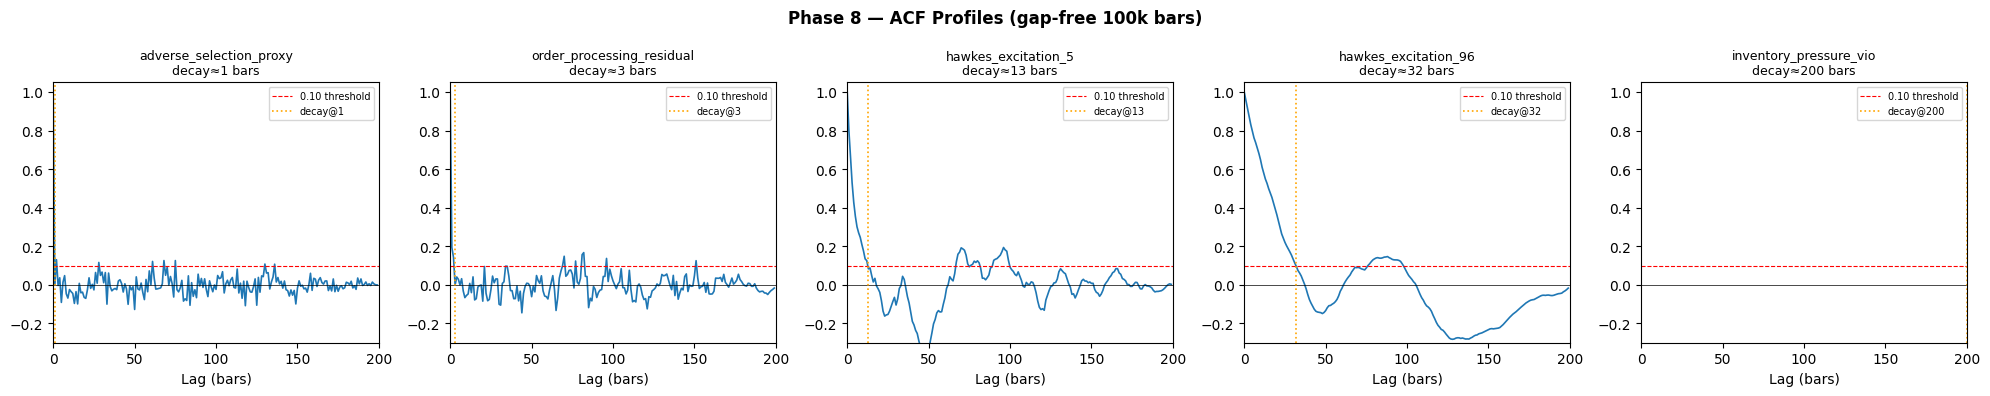

In [14]:
# Gap-free consecutive segment (Phase 7v2 lesson: random sampling corrupts ACF)
ACF_N   = 100_000
ACF_MAX = 200
start   = N // 4   # skip warmup

fig, axes = plt.subplots(1, len(candidates), figsize=(4*len(candidates), 4))
if len(candidates) == 1: axes = [axes]

for ax, (name, feat) in zip(axes, candidates.items()):
    segment = feat[start:start+ACF_N].astype(np.float64)
    segment -= segment.mean()
    # Use numpy correlate for speed
    acf_vals = np.correlate(segment[:ACF_MAX+1], segment[:ACF_MAX+1], mode="full")
    acf_vals  = acf_vals[ACF_MAX:] / acf_vals[ACF_MAX]
    ax.plot(acf_vals[:ACF_MAX], lw=1.2)
    ax.axhline(0.1, color="red", ls="--", lw=0.8, label="0.10 threshold")
    ax.axhline(0,   color="black", lw=0.5)
    decay_bar = next((i for i, v in enumerate(acf_vals) if v < 0.1), ACF_MAX)
    ax.axvline(decay_bar, color="orange", ls=":", lw=1.2, label=f"decay@{decay_bar}")
    ax.set_title(f"{name}\ndecay≈{decay_bar} bars", fontsize=9)
    ax.set_xlabel("Lag (bars)"); ax.legend(fontsize=7)
    ax.set_xlim(0, ACF_MAX); ax.set_ylim(-0.3, 1.05)

plt.suptitle("Phase 8 — ACF Profiles (gap-free 100k bars)", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig("phase8_acf.png", dpi=120, bbox_inches="tight"); plt.show()


## 9. Orthogonality (Correlation Matrix)

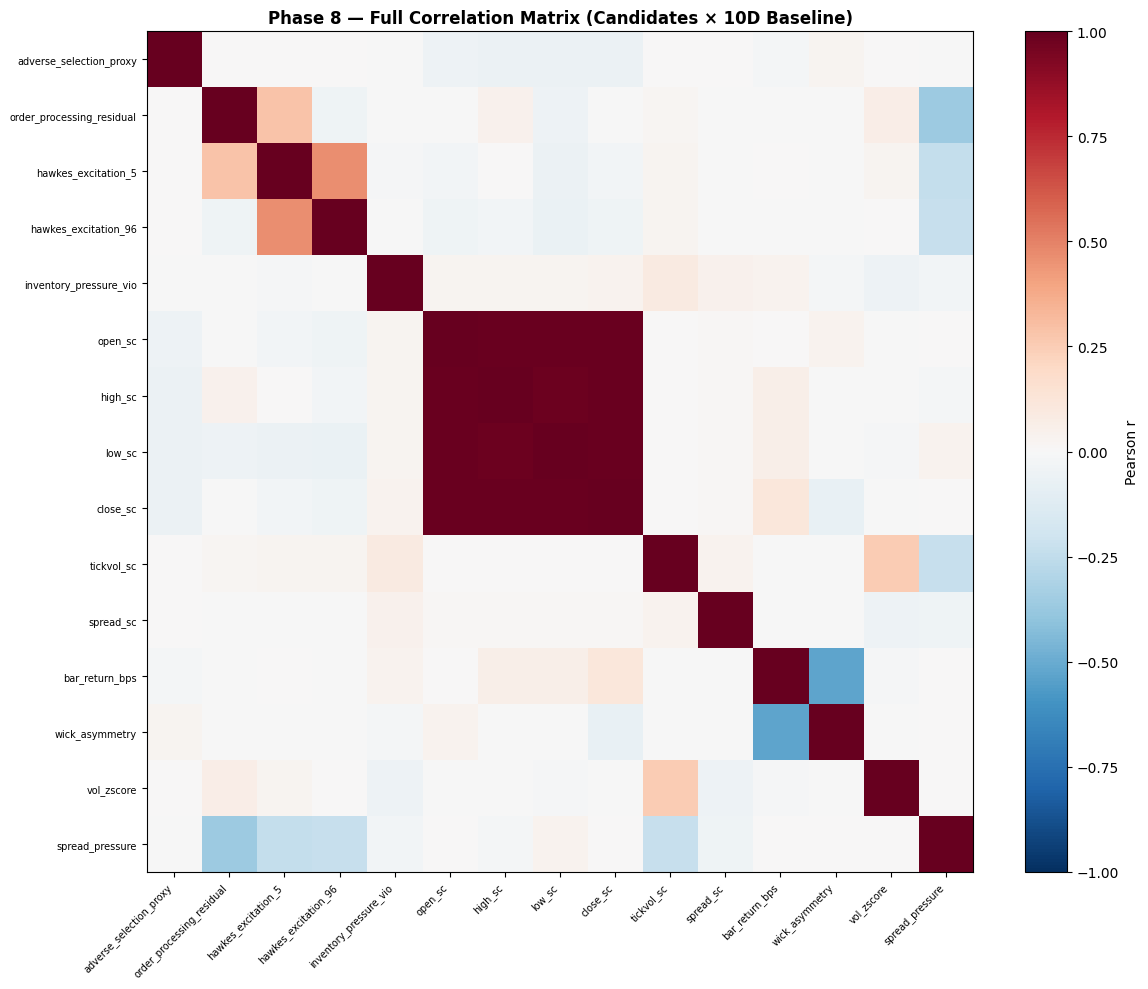


=== Max External |r| per Candidate ===
  adverse_selection_proxy          max|r|=0.058  (vs close_sc)
  order_processing_residual        max|r|=0.365  (vs spread_pressure)
  hawkes_excitation_5              max|r|=0.237  (vs spread_pressure)
  hawkes_excitation_96             max|r|=0.232  (vs spread_pressure)
  inventory_pressure_vio           max|r|=0.088  (vs tickvol_sc)


In [15]:
from scipy.stats import pearsonr

cand_list  = list(candidates.items())
n_cands    = len(cand_list)
n_base     = 10
total      = n_cands + n_base

all_feats  = [f for _, f in cand_list] + [features_10d[:, i] for i in range(n_base)]
all_labels = [n for n, _ in cand_list] + BASELINE_NAMES

corr_mat = np.zeros((total, total))
for i in range(total):
    for j in range(total):
        corr_mat[i, j] = pearsonr(all_feats[i], all_feats[j])[0]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(total)); ax.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(total)); ax.set_yticklabels(all_labels, fontsize=7)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Phase 8 — Full Correlation Matrix (Candidates × 10D Baseline)", fontweight="bold")
plt.tight_layout(); plt.savefig("phase8_correlation.png", dpi=120, bbox_inches="tight"); plt.show()

print("\n=== Max External |r| per Candidate ===")
for i, (name, _) in enumerate(cand_list):
    ext_cors = [abs(corr_mat[i, n_cands+j]) for j in range(n_base)]
    max_cor  = max(ext_cors); max_nm = BASELINE_NAMES[ext_cors.index(max_cor)]
    print(f"  {name:<32} max|r|={max_cor:.3f}  (vs {max_nm})")
